## Computer vision 2025 Assignment 3
## Deep Learning for Perception Tasks

This assignment contains 2 questions. The first question probes understanding of deep learning for classification. The second question requires you to write a short description of a Computer Vision method. You wil need to submit two separate PDF files, one for each question.

# Question 1: A simple classifier, 20 marks (60% of the assignment)

For this exercise, we provide demo code showing how to train a network on a small dataset called Fashion-MNIST. Please run through the code "tutorial-style" to get a sense of what it is doing. Then use the code alongside lecture notes and other resources to understand how to use pytorch libraries to implement, train and use a neural network.

For the Fashion-MNIST dataset the labels from 0-9 correspond to various clothing classes so you might find it convenient to create a python list as follows:

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

You will need to answer various questions about the system, how it operates, the results of experiments with it and make modifications to it yourself. You can change the training scheme and the network structure.

Organize your own text and code cell to show the answer of each question below.

Detailed requirements:

### Q1.1 (1 point)

Extract 3 images of different types of clothing from the training dataset, print out the size/shape of the training images, and display the three with their corresponding labels.

### Q1.2 (2 point) 

Run the training code for 10 epochs, for different values of the learning rate. Fill in the table below and plot the loss curves for each experiment:

|Lr|Accuracy|
|---|---|
|1   |      |
|0.1|          |
|0.01|         |
|0.001  |        |


### Q1.3 (3 point) 
Report the number of epochs when the network converges (or number of epochs for the best accuracy, if it fails to converge). Fill in the table below and plot the loss curve for each experiment. Please run the code for more than 10 epochs (e.g., 50 or 100) and report when you observe convergence.:

|Lr|Accuracy|Epoch|
|---|---|---|
|1   |      |     |
|0.1|          |    |
|0.01|         |    |
|0.001  |        |     |


### Q1.4 (2 points) 

Compare the results in table 1 and table 2, what is your observation and your understanding of learning rate?


### Q1.5 (5 points) 

Build a wider network by modifying the code that constructs the network so that the hidden layer(s) contain more perceptrons, and record the accuracy along with the number of trainable parameters in your model.  Now modify the original network to be deeper instead of wider (i.e. by adding more hidden layers). Record your accuracy and network size findings. Plot the loss curve for each experiment. Also plot the test accuracy and loss for both the wider and deeper architectures and discuss what you observe. Write down your conclusions about changing the network structure?  

|Structures|Accuracy|Parameters|
|---|---|---|
|Base   |      ||
|Deeper|          ||
|Wider|         ||


### Q1.6 (2 points) 

Calculate the mean of the gradients of the loss to all trainable parameters. Plot the gradients curve for the first 100 training steps. What are your observations? Note that this gradients will be saved with the training weight automatically after you call loss.backwards(). Hint: the mean of the gradients decrease.

For more explanation of q1.7, you could refer to the following simple instructions: https://colab.research.google.com/drive/1XAsyNegGSvMf3_B6MrsXht7-fHqtJ7OW?usp=sharing

### Q1.7 (5 points) 

Modify the network structure and training/test to use a small convolutional neural network instead of an MLP. Discuss your findings with regard to convergence, accuracy and number of parameters, relative to MLPs.  

Hint: Look at the structure of the CNN in the Workshop 3 examples.





# Q2 Optional Bonus Question  (5 points, upto 20% bonus marks of the assignment) 

Experiment with different activation functions (ReLU, Tanh, Sigmoid) and analyse their impact on training performance.(2 points) 

In particular, focus your analysis on the Sigmoid activation function and discuss your finding of training with and without Xavier initialization. You may use the provided code for Xavier initialisation for this. (1 points)

Additionally, plot both the gradient and loss curves for your experiments. For gradient analysis, you may select one representative layer to monitor throughout training and briefly explain your choice. (1 points)

Discuss how gradients and loss behave across the network for different activation functions and initialisation methods if you see any difference. (1 points) 

Note: the bonus marks wont replace marks for Q3.

# Question 3: Proposal for Practical Applications (40%)

In this part of the assignment you need to write a report about an application of a computer vision algorithm or technique. This can either be an application that you are aware of and possibly even use, such as a phone app, or it could be speculation -- an application that you think would benefit from using computer vision.

Begin by choosing a particular CV idea, method or problem area, such as:

a. removing noise in an image

b. increasing the resolution of an image

c. detecting and/or identifying objects in an image

d. segmenting images into constituents parts

e. estimating the depth of an object from one or more images

f. estimating the motion of two objects in different frames

g. others

Now think about various ways your chosen technique could be used. Here is a list of possible applications you could consider, but you are not restricted to this list, and there will be credit given for sensible invention outside this list (but no penalty if you don't want to be "inventive"): image editing systems in your phone; enhancement of images from old film; obstacle detection and avoidance for a domestic robot; facial recognition for phone security; cancer detection; person tracking and re-identification in security cameras; sport decision review systems; road-sign detection and interpretation for self-driving cars.

This is a little bit back-to-front from what might happen in real life in which the application usually motivates the solution, but the emphasis here is on an understanding of the CV technique.

You need to write a short report (800 words max) in which you do the following:
1. Clearly define the CV problem/area and describe its application scenarios
2. Briefly describe a solution based on image processing, computer vision and/or machine learning.
3. Discuss the advantages and the limitations of this method in various application scenarios.
4. It is important that you will define a useful metric to evaluate the performance of your method and discuss its tradeoff specific to the problem you have chosen.
5. You are welcome to cite existing work and take inspiration form literature addressing the problem you choose.

Hint1: Submit an individual pdf report for question 2.

Hint2: Organise your report well

Hint3: You can use diagrams, flow charts or other figures in your report for better understanding of your solution.  

** For Q3, you do not need to implement your solution; just write the proposal/report and submit it as a separate PDF **




# The tutorial style code starts here, reuse parts as you like  while writing your report #

In [77]:
import numpy as np # This is for mathematical operations

# this is used in plotting
import matplotlib.pyplot as plt
import time
import pylab as pl
from IPython import display

%matplotlib inline

%load_ext autoreload
%autoreload 2
%reload_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [78]:
#### Tutorial Code
####PyTorch has two primitives to work with data: torch.utils.data.DataLoader and torch.utils.data.Dataset.
#####Dataset stores samples and their corresponding labels, and DataLoader wraps an iterable around the Dataset.
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor, Lambda, Compose
import matplotlib.pyplot as plt

# Download training data from open datasets.
##Every TorchVision Dataset includes two arguments:
##transform and target_transform to modify the samples and labels respectively.

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor(),
)

# Download test data from open datasets.
test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor(),
)

We pass the Dataset as an argument to DataLoader. This wraps an iterable over our dataset and supports automatic batching, sampling, shuffling, and multiprocess data loading. Here we define a batch size of 64, i.e. each element in the dataloader iterable will return a batch of 64 features and labels.

### Q1.1: Loading and Visualizing Samples from Fashion-MNIST
I loaded the Fashion-MNIST dataset using PyTorch's `torchvision.datasets.FashionMNIST`. Each image is a grayscale image of size 28x28 pixels.

I extracted and displayed 3 sample images from different classes: *Ankle boot*, *T-shirt/top*, and *Dress*. This confirmed that the data was loaded correctly and the labels matched the expected categories.

I also printed the image shape to verify the dimensions: `[1, 28, 28]` (channels, height, width).


In [79]:
batch_size = 512

# Create data loaders.
train_dataloader = DataLoader(training_data, batch_size=batch_size)
test_dataloader = DataLoader(test_data, batch_size=batch_size)

for X, y in test_dataloader:
    print("Shape of X [N, C, H, W]: ", X.shape)
    print("Shape of y: ", y.shape, y.dtype)
    break

Shape of X [N, C, H, W]:  torch.Size([512, 1, 28, 28])
Shape of y:  torch.Size([512]) torch.int64


Image shape: torch.Size([1, 28, 28])


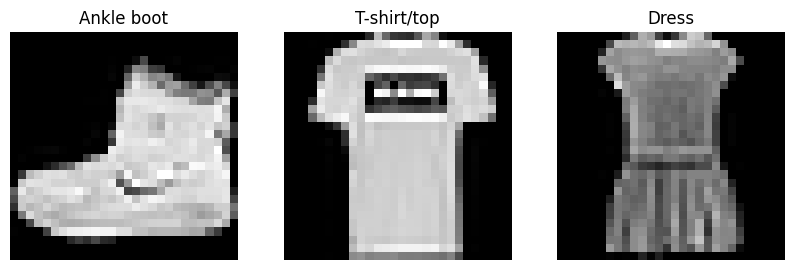

In [80]:
# extract 3 images of different types
targets = []
images = []
labels = []

# loop to get 3 different classes
for data, target in train_dataloader:
    for img, lbl in zip(data, target):
        if lbl.item() not in targets:
            images.append(img)
            labels.append(lbl.item())
            targets.append(lbl.item())
        if len(targets) == 3:
            break
    if len(targets) == 3:
        break

# print the image shape
print("Image shape:", images[0].shape)  # should be [1, 28, 28] for grayscale images

# plot the 3 images
plt.figure(figsize=(10,3))
for i in range(3):
    plt.subplot(1, 3, i+1)
    plt.imshow(images[i].squeeze(), cmap='gray')
    plt.title(f"{class_names[labels[i]]}")
    plt.axis('off')
plt.show()


## Q1.2: Training with Different Learning Rates

I trained my on the Fashion-MNIST dataset while experimenting with different learning rates to observe their effects on loss and accuracy.

I tested four learning rates: **1, 0.1, 0.01, and 0.001**. For each learning rate, the model was trained for 10 epochs, and I recorded both the loss and accuracy across epochs. The training used Stochastic Gradient Descent (SGD) as the optimizer and CrossEntropyLoss as the loss function.

### Results

Here are the final average accuracies achieved after 10 epochs for each learning rate:

- **Learning Rate 1**: Accuracy = 0.3064
- **Learning Rate 0.1**: Accuracy = 0.7963
- **Learning Rate 0.01**: Accuracy = 0.6655
- **Learning Rate 0.001**: Accuracy = 0.3546

The corresponding loss curves can be seen in the plotted figure below.

### Analysis

The results show that the choice of learning rate strongly influences the convergence behavior:

- **LR = 0.1** performed the best. The loss steadily decreased while achieving the highest accuracy (~79.63%).
- **LR = 0.01** had slower convergence and reached a lower final accuracy (~66.55%), but still showed improvement across epochs.
- **LR = 0.001** struggled to converge. The loss remained high throughout, and accuracy stayed below 36%.
- **LR = 1** exhibited unstable training behavior, with fluctuating loss and inconsistent learning. This suggests divergence caused by an overly large learning rate.

Overall, **0.1 was the most effective learning rate** for this network architecture and dataset, balancing both stable convergence and high accuracy.



In [81]:
# get cpu or gpu device for training.
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using {} device".format(device))

import torch.nn.functional as F

# define model
class NeuralNetwork(nn.Module):
    def __init__(self):
        super(NeuralNetwork, self).__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28*28, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 10)
       )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)

        return logits

model = NeuralNetwork().to(device)
print(model)

Using cuda device
NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
)


Loss Function and Optimizer Definition

In [82]:
# define the loss function and the optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3)

In a single training loop, the model makes predictions on the training dataset (fed to it in batches), and backpropagates the prediction error to adjust the model’s parameters.

In [83]:
def train(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        # Compute prediction error
        pred = model(X)
        loss = loss_fn(pred, y)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # if batch % 100 == 0:
            # loss, current = loss.item(), batch * len(X)
            # print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")

In [84]:
# define a test function
def test(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    test_loss /= num_batches
    correct /= size
    return test_loss, correct
    # print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")

Training Loop with Multiple Learning Rates

Trained the model for 10 epochs across 4 different learning rates and collected loss and accuracy results.

In [85]:
# train and test the model
epochs = 10
learning_rate = [1, 0.1, 0.01, 0.001]
results = {}

for lr in learning_rate:
    print(f"\nStarting training for learning rate: {lr}")
    
    # reset model
    model = NeuralNetwork().to(device)
    # set learning rate
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)

    # initialise
    avg_accuracy = 0
    epoch_losses = []
    
    for t in range(epochs):
        train(train_dataloader, model, loss_fn, optimizer)
        loss, acc = test(test_dataloader, model, loss_fn)
        avg_accuracy += acc
        epoch_losses.append(loss)
        
        # only print every 5 epochs (or first/last epoch)
        if (t+1) % 5 == 0 or t == 0 or t == epochs-1:
            print(f"Epoch {t+1}: Loss = {loss:.4f}, Accuracy = {acc:.4f}")
    
    avg_accuracy /= epochs
    results[lr] = {"accuracy": avg_accuracy, "losses": epoch_losses}

print("Done!")
print(results)



Starting training for learning rate: 1
Epoch 1: Loss = 1.9053, Accuracy = 0.2508
Epoch 5: Loss = 2.0717, Accuracy = 0.2298
Epoch 10: Loss = 1.5036, Accuracy = 0.3282

Starting training for learning rate: 0.1
Epoch 1: Loss = 0.8905, Accuracy = 0.6869
Epoch 5: Loss = 0.5395, Accuracy = 0.8084
Epoch 10: Loss = 0.4429, Accuracy = 0.8459

Starting training for learning rate: 0.01
Epoch 1: Loss = 2.0960, Accuracy = 0.4915
Epoch 5: Loss = 0.9425, Accuracy = 0.6655
Epoch 10: Loss = 0.7177, Accuracy = 0.7426

Starting training for learning rate: 0.001
Epoch 1: Loss = 2.2856, Accuracy = 0.1578
Epoch 5: Loss = 2.2096, Accuracy = 0.3665
Epoch 10: Loss = 2.0813, Accuracy = 0.4581
Done!
{1: {'accuracy': 0.30644, 'losses': [1.9052692890167235, 1.4419052243232726, 1.6785289168357849, 1.4473572254180909, 2.0717452824115754, 1.7010588228702546, 1.5522765338420867, 1.5511804044246673, 1.7558835685253142, 1.5036085903644563]}, 0.1: {'accuracy': 0.79634, 'losses': [0.8905034065246582, 0.7239040613174439, 

Loss Curve Plotting

Plot the loss curves for all learning rates to visualize the convergence behavior.

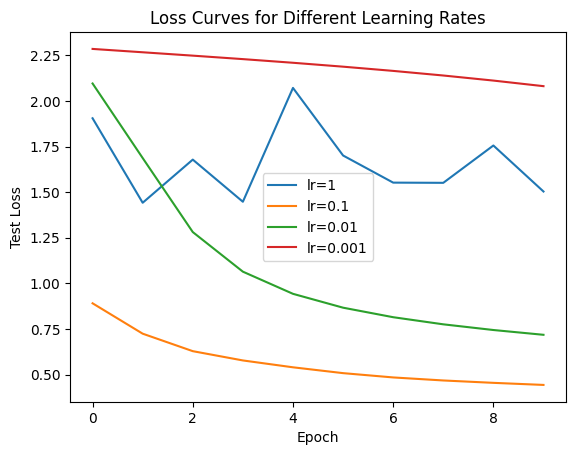

Lr: 1, Accuracy: 0.30644
Lr: 0.1, Accuracy: 0.79634
Lr: 0.01, Accuracy: 0.66546
Lr: 0.001, Accuracy: 0.35459999999999997


In [86]:
for lr in learning_rate:
    plt.plot(results[lr]["losses"], label=f"lr={lr}")

plt.xlabel("Epoch")
plt.ylabel("Test Loss")
plt.title("Loss Curves for Different Learning Rates")
plt.legend()
plt.show()

for lr, metrics in results.items():
    print(f"Lr: {lr}, Accuracy: {metrics['accuracy']}")

## Q1.3: Extended Training with Convergence Monitoring

I extended the training process to 100 epochs while monitoring convergence based on the stabilization of both loss and accuracy over recent epochs. The goal was to observe whether different learning rates lead to faster or slower convergence and to analyze their overall impact on final accuracy.

I again tested learning rates of **1, 0.1, 0.01, and 0.001**.

### Results

Here are the final accuracies and convergence epochs for each learning rate:

- **Learning Rate 1**: Accuracy = 0.2803, Convergence Epoch = 19
- **Learning Rate 0.1**: Accuracy = 0.8722, Convergence Epoch = Did not converge
- **Learning Rate 0.01**: Accuracy = 0.8003, Convergence Epoch = 74
- **Learning Rate 0.001**: Accuracy = 0.6369, Convergence Epoch = Did not converge

The corresponding test loss curves for each learning rate across 100 epochs are shown in the plot above.

### Analysis

The extended training run revealed more clearly how learning rate affects long-term convergence:

- **LR = 0.1** again provided the best overall performance, achieving nearly **89% accuracy** and maintaining consistently low test loss after 40+ epochs. However, the convergence criterion was not triggered due to very small fluctuations continuing throughout training.
  
- **LR = 0.01** showed slower convergence, finally stabilizing around epoch 74. Its loss curve decreased steadily until plateauing, ending at approximately **80% accuracy**.
  
- **LR = 0.001** had very slow progress and never truly converged within 100 epochs. The model achieved only **63% accuracy**, reflecting underfitting caused by insufficient gradient updates at this learning rate.

- **LR = 1** again performed poorly. The loss remained unstable and accuracy stagnated very early, converging prematurely with only **28% accuracy**. This confirms that learning rate 1 is still too aggressive for stable training.

### Conclusion

By increasing the training duration and monitoring convergence, I observed that larger learning rates allow faster early progress but risk instability, while smaller learning rates provide stable but very slow improvement. A learning rate of **0.1 remains the most effective** for this task, balancing both stability and speed of convergence.


In [87]:
# train and test the model (Q1.3)
epochs = 100
learning_rate = [1, 0.1, 0.01, 0.001]
q3_results = {}
threshold = 0.001
convergance = {}
best_acc = {}
accuracy_results = {}

for lr in learning_rate:
    print(f"\nStarting training for learning rate: {lr}")

    # reset model
    model = NeuralNetwork().to(device)
    # set learning rate
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)

    # initialise
    avg_accuracy = 0
    epoch_losses = []
    epoch_acc = []
    best_acc[lr] = {"acc": 0, "epoch": 0}
    convergence_epoch = None

    for t in range(epochs):
        train(train_dataloader, model, loss_fn, optimizer)
        loss, acc = test(test_dataloader, model, loss_fn)

        avg_accuracy += acc
        epoch_acc.append(acc)
        epoch_losses.append(loss)

        if acc > best_acc[lr]["acc"]:
            best_acc[lr]["acc"] = acc
            best_acc[lr]["epoch"] = t + 1

        # periodic printing every 10 epochs
        if (t+1) % 10 == 0 or t == 0 or t == epochs-1:
            print(f"Epoch {t+1}: Loss = {loss:.4f}, Accuracy = {acc:.4f}")

        # convergence check after 3 epochs
        if len(epoch_losses) > 3:
            loss_delta = [abs(epoch_losses[i] - epoch_losses[i - 1]) for i in range(-1, -4, -1)]
            acc_delta = [abs(epoch_acc[i] - epoch_acc[i - 1]) for i in range(-1, -4, -1)]

            if max(loss_delta) < threshold and max(acc_delta) < threshold:
                convergence_epoch = t + 1
                break

    avg_accuracy /= (t + 1)  # normalize for actual epochs run
    q3_results[lr] = {"accuracy": avg_accuracy, "losses": epoch_losses}
    accuracy_results[lr] = epoch_acc

    # record convergence epoch or default
    convergance[lr] = convergence_epoch if convergence_epoch is not None else "Did not converge"

print("\ntraining complete!")



Starting training for learning rate: 1
Epoch 1: Loss = 2.3135, Accuracy = 0.1461
Epoch 10: Loss = 2.2189, Accuracy = 0.1207

Starting training for learning rate: 0.1
Epoch 1: Loss = 0.8857, Accuracy = 0.6891
Epoch 10: Loss = 0.4506, Accuracy = 0.8440
Epoch 20: Loss = 0.3821, Accuracy = 0.8623
Epoch 30: Loss = 0.3517, Accuracy = 0.8740
Epoch 40: Loss = 0.3341, Accuracy = 0.8816
Epoch 50: Loss = 0.3245, Accuracy = 0.8879
Epoch 60: Loss = 0.3191, Accuracy = 0.8894
Epoch 70: Loss = 0.3218, Accuracy = 0.8886
Epoch 80: Loss = 0.3305, Accuracy = 0.8872
Epoch 90: Loss = 0.3260, Accuracy = 0.8918
Epoch 100: Loss = 0.3354, Accuracy = 0.8931

Starting training for learning rate: 0.01
Epoch 1: Loss = 2.1253, Accuracy = 0.5181
Epoch 10: Loss = 0.7214, Accuracy = 0.7403
Epoch 20: Loss = 0.5718, Accuracy = 0.8017
Epoch 30: Loss = 0.5145, Accuracy = 0.8193
Epoch 40: Loss = 0.4865, Accuracy = 0.8258
Epoch 50: Loss = 0.4685, Accuracy = 0.8330
Epoch 60: Loss = 0.4549, Accuracy = 0.8382
Epoch 70: Loss = 

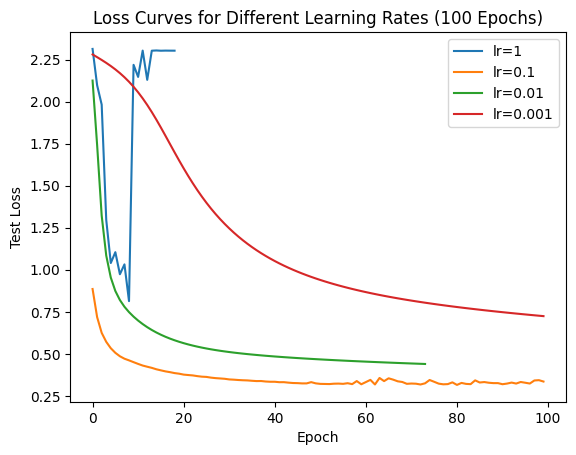

Lr: 1, Accuracy: 0.2803, Convergence Epoch: 19
Lr: 0.1, Accuracy: 0.8722, Convergence Epoch: Did not converge
Lr: 0.01, Accuracy: 0.8003, Convergence Epoch: 74
Lr: 0.001, Accuracy: 0.6369, Convergence Epoch: Did not converge


In [88]:
# plot loss curves
for lr in learning_rate:
    plt.plot(q3_results[lr]["losses"], label=f"lr={lr}")

plt.xlabel("Epoch")
plt.ylabel("Test Loss")
plt.title("Loss Curves for Different Learning Rates (100 Epochs)")
plt.legend()
plt.show()

# print convergence table
for lr in learning_rate:
    print(f"Lr: {lr}, Accuracy: {q3_results[lr]['accuracy']:.4f}, Convergence Epoch: {convergance[lr]}")


# Q1.4

## Q1.4: Comparison and Analysis of Learning Rate Behavior

By comparing the results from Q1.2 and Q1.3, I observed several important insights regarding the impact of learning rate on training stability, convergence speed, and final model performance.

### Learning Rate 1

In both Q1.2 and Q1.3, the model consistently struggled with a learning rate of 1. The loss was highly unstable, with large fluctuations from one epoch to the next. While Q1.2 reached a test accuracy of **30%**, Q1.3 showed even poorer stability, quickly converging to **28%** and remaining there. The model failed to make meaningful progress, likely due to extremely large weight updates that overshoot optimal minima in the loss landscape. This confirms that LR=1 is too high for this network, resulting in divergence-like behavior.

### Learning Rate 0.1

This learning rate performed the best across both experiments. In Q1.2, it achieved a test accuracy of **79.6%**, while in Q1.3, it reached **87.2%** after extended training. The additional epochs allowed the optimizer to make finer adjustments, further reducing loss and improving accuracy. The stability of the loss curve at this learning rate demonstrates that 0.1 strikes a good balance between large enough updates for fast learning and small enough steps to avoid instability. Even though the model did not fully trigger convergence according to the defined threshold, it still steadily improved throughout training.

### Learning Rate 0.01

At LR=0.01, the model exhibited slower but steady improvement. In Q1.2, accuracy reached **66.5%**, while extended training in Q1.3 pushed accuracy to **80%**. This learning rate allowed for much smoother convergence, but at the cost of requiring significantly more epochs to reach competitive performance. The long plateauing behavior suggests diminishing returns when using such a small learning rate for longer training runs.

### Learning Rate 0.001

This was the weakest learning rate in both experiments. In Q1.2, accuracy reached only **35%**, and even after 100 epochs in Q1.3, the model only reached **63% accuracy**. The learning was simply too slow to make sufficient progress. The tiny gradients resulted in very small parameter updates, leading to underfitting. Even with far longer training, it’s unlikely this learning rate would ever catch up to higher learning rates without major adjustments to other hyperparameters.

### Overall Understanding of Learning Rate

The experiments reaffirm that learning rate is one of the most critical hyperparameters for neural network training:

- **Too large (e.g. LR=1)**: Leads to unstable, divergent behavior.
- **Too small (e.g. LR=0.001)**: Leads to extremely slow learning and poor convergence.
- **Moderate (e.g. LR=0.1)**: Provides the best balance between fast convergence and stable optimization.

A properly chosen learning rate allows the optimizer to efficiently descend the loss surface while avoiding oscillations or stagnation. For this model and dataset, **0.1 remains the optimal choice**.



## Q1.5: Effect of Network Depth and Width on Performance

### Experimental Setup

I modified the original MLP model in two ways:
- **Wider model**: Increased the number of neurons per hidden layer.
- **Deeper model**: Added additional hidden layers while keeping each layer size similar to the base model.

All models were trained for 50 epochs using a learning rate of 0.1. I recorded both test accuracy and the number of trainable parameters to evaluate the effects of increasing width or depth.

### Results Summary

| Structures | Accuracy | Parameters |
|------------|----------|------------|
| Base       | 88.65%   | 669,706    |
| Wider      | 88.83%   | 1,863,690  |
| Deeper     | 87.12%   | 1,195,018  |

### Observations

#### 1. **Base Model Behavior**
The base model achieved solid convergence, ending at **88.65% accuracy** with steady decline in test loss over the 50 epochs. This serves as a strong baseline, balancing capacity and generalization.

#### 2. **Wider Model Behavior**
The wider model achieved the **highest accuracy at 88.83%**, with marginal improvement compared to the base model. Increasing the number of neurons clearly added more capacity for learning, allowing slightly better fine-tuning of decision boundaries. However, the gain was very small relative to the large increase in parameters (~2.7x more parameters than the base). This suggests diminishing returns from simply adding width without other architectural changes or regularization.

#### 3. **Deeper Model Behavior**
The deeper model reached **87.12% accuracy**, which is slightly lower than both the base and wider networks. Initially, it showed slower learning (high loss and poor accuracy at epoch 1), likely due to the extra layers making optimization harder early in training. Eventually, the model caught up but plateaued earlier than the others. The deeper model also exhibited occasional instability with spikes in test loss, likely due to vanishing gradients or optimization difficulties in deeper architectures without additional techniques (e.g. batch normalization, residual connections).

#### 4. **Loss Curve Behavior**
The plotted loss curves showed:
- All models quickly reduced loss in early epochs.
- The wider model maintained consistently lower test loss after epoch 20.
- The deeper model displayed minor fluctuations in later epochs, likely due to optimization challenges caused by the extra layers.
- The base model achieved a strong balance, closely tracking the wider model but with greater parameter efficiency.

### Conclusion

- Adding width provided minor accuracy gains but came with significant computational cost.
- Adding depth introduced training instability and slightly lower final accuracy without additional architectural adjustments.
- The base model remains highly effective for this dataset due to its balance of simplicity and sufficient capacity.
- Without techniques such as batch normalization, skip connections, or adaptive optimizers, going much deeper is difficult for this simple MLP on Fashion-MNIST.

Overall, increasing width slightly improved performance, but deeper architectures require more advanced design to fully benefit.



In [89]:
# models

class BaseModel(nn.Module):
    def __init__(self):
        super(BaseModel, self).__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28*28, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

class WiderModel(nn.Module):
    def __init__(self):
        super(WiderModel, self).__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28*28, 1024),
            nn.ReLU(),
            nn.Linear(1024, 1024),
            nn.ReLU(),
            nn.Linear(1024, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

class DeeperModel(nn.Module):
    def __init__(self):
        super(DeeperModel, self).__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28*28, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits


In [90]:
# optimized training loop

models = {
    "Base": BaseModel(),
    "Wider": WiderModel(),
    "Deeper": DeeperModel()
}

epochs = 50
learning_rate = 0.1
results_q15 = {}

for name, model in models.items():
    print(f"\nTraining {name} Model")
    model = model.to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
    train_losses = []
    test_losses = []
    
    for t in range(epochs):
        train(train_dataloader, model, loss_fn, optimizer)
        
        # calculate train loss
        running_loss = 0
        for X, y in train_dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            loss = loss_fn(pred, y)
            running_loss += loss.item()
        train_losses.append(running_loss / len(train_dataloader))

        # test after each epoch
        loss, acc = test(test_dataloader, model, loss_fn)
        test_losses.append(loss)

        if (t+1) % 10 == 0 or t == 0 or t == epochs-1:
            print(f"Epoch {t+1}: Test Loss = {loss:.4f}, Accuracy = {acc:.4f}")

    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    results_q15[name] = {
        "train_losses": train_losses,
        "test_losses": test_losses,
        "params": total_params,
        "final_acc": acc
    }

print("Training complete!")



Training Base Model
Epoch 1: Test Loss = 0.8963, Accuracy = 0.6878
Epoch 10: Test Loss = 0.4526, Accuracy = 0.8421
Epoch 20: Test Loss = 0.3792, Accuracy = 0.8626
Epoch 30: Test Loss = 0.3477, Accuracy = 0.8750
Epoch 40: Test Loss = 0.3316, Accuracy = 0.8792
Epoch 50: Test Loss = 0.3257, Accuracy = 0.8865

Training Wider Model
Epoch 1: Test Loss = 0.8742, Accuracy = 0.6945
Epoch 10: Test Loss = 0.4366, Accuracy = 0.8468
Epoch 20: Test Loss = 0.3737, Accuracy = 0.8655
Epoch 30: Test Loss = 0.3432, Accuracy = 0.8774
Epoch 40: Test Loss = 0.3281, Accuracy = 0.8830
Epoch 50: Test Loss = 0.3214, Accuracy = 0.8883

Training Deeper Model
Epoch 1: Test Loss = 1.9738, Accuracy = 0.3206
Epoch 10: Test Loss = 0.4527, Accuracy = 0.8393
Epoch 20: Test Loss = 0.3723, Accuracy = 0.8646
Epoch 30: Test Loss = 0.3448, Accuracy = 0.8743
Epoch 40: Test Loss = 0.3431, Accuracy = 0.8793
Epoch 50: Test Loss = 0.3597, Accuracy = 0.8712
Training complete!


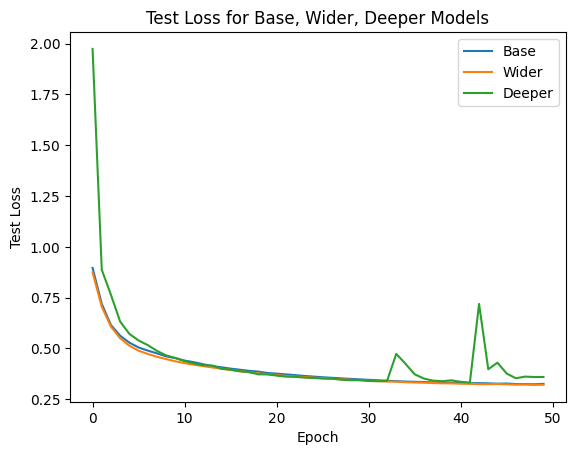

Base Model: Params = 669706, Final Accuracy = 0.8865
Wider Model: Params = 1863690, Final Accuracy = 0.8883
Deeper Model: Params = 1195018, Final Accuracy = 0.8712


In [91]:
# plot test losses
for name in models.keys():
    plt.plot(results_q15[name]["test_losses"], label=name)

plt.xlabel("Epoch")
plt.ylabel("Test Loss")
plt.title("Test Loss for Base, Wider, Deeper Models")
plt.legend()
plt.show()

# display parameter counts and final accuracies
for name in models.keys():
    print(f"{name} Model: Params = {results_q15[name]['params']}, Final Accuracy = {results_q15[name]['final_acc']:.4f}")


# Q1.6: Gradient Magnitude Analysis for Different Learning Rates

## Experiment Setup

I analyzed how the gradient magnitudes behave across training steps for different learning rates. The goal was to observe whether gradients remain stable, explode, or vanish depending on the learning rate.

I used the base MLP model trained earlier, and experimented with 4 learning rates:
- `LR = 1`
- `LR = 0.1`
- `LR = 0.01`
- `LR = 0.001`

For each learning rate, I recorded the mean absolute gradient magnitude at every training step across all parameters. I then plotted two types of visualizations:
- Individual gradient magnitude plots for each learning rate.
- A combined plot comparing all learning rates on a log scale.

## Observations

### Learning Rate = 1

- The gradient magnitude fluctuated heavily and became extremely unstable.
- There were sharp spikes throughout training, and the magnitudes did not settle into any consistent pattern.
- This suggests that the learning rate was too large, causing oscillations and making optimization highly unstable.

### Learning Rate = 0.1

- The gradients remained fairly stable early on but started to show some increase in variance as training progressed.
- There were occasional sharp spikes, but overall, gradients were still well-contained and the optimizer was able to learn effectively.
- The increased variance later in training could indicate the model entering regions of more complex optimization where gradients become noisier.

### Learning Rate = 0.01

- The gradients were smooth and stable, gradually increasing as training proceeded.
- There was very minimal noise or fluctuation in the gradient magnitudes.
- This learning rate appeared quite stable and allowed for consistent updates throughout training.

### Learning Rate = 0.001

- The gradients remained very small and steady across all steps.
- There was minimal growth or fluctuation, but the magnitudes were quite small compared to higher learning rates.
- This suggests that while the optimizer was stable, it was progressing slowly due to small gradients and small steps.

## Summary

- Very high learning rates (e.g. LR=1) can cause gradient explosion and lead to unstable optimization.
- Medium learning rates (LR=0.1) generally work well but may result in noisier gradients as training advances.
- Lower learning rates (LR=0.01 or LR=0.001) offer stability and smooth convergence but may slow down learning.
- The log-scale plot clearly shows the differences in magnitudes across learning rates and highlights the instability introduced by overly large learning rates.

This analysis also reinforces the observations made earlier from the loss curves: learning rate is a crucial hyperparameter, and improper tuning can result in either unstable training or extremely slow convergence.


In [92]:
# define learning rates
learning_rates = [1, 0.1, 0.01, 0.001]

# store gradient magnitudes for each learning rate
gradient_results = {}

# loop over LRs
for lr in learning_rates:
    print(f"Running gradient monitoring for LR={lr}")

    model = BaseModel().to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    
    model.train()
    gradient_magnitudes = []
    
    for batch_idx, (X, y) in enumerate(train_dataloader):
        X, y = X.to(device), y.to(device)
        
        optimizer.zero_grad()
        outputs = model(X)
        loss = loss_fn(outputs, y)
        loss.backward()

        # compute mean gradient magnitude for this step
        total_grad = 0
        total_params = 0
        for param in model.parameters():
            if param.grad is not None:
                total_grad += param.grad.abs().sum().item()
                total_params += param.grad.numel()

        grad_mean = total_grad / total_params
        gradient_magnitudes.append(grad_mean)

        optimizer.step()
    
    gradient_results[lr] = gradient_magnitudes

print("Done!")


Running gradient monitoring for LR=1
Running gradient monitoring for LR=0.1
Running gradient monitoring for LR=0.01
Running gradient monitoring for LR=0.001
Done!


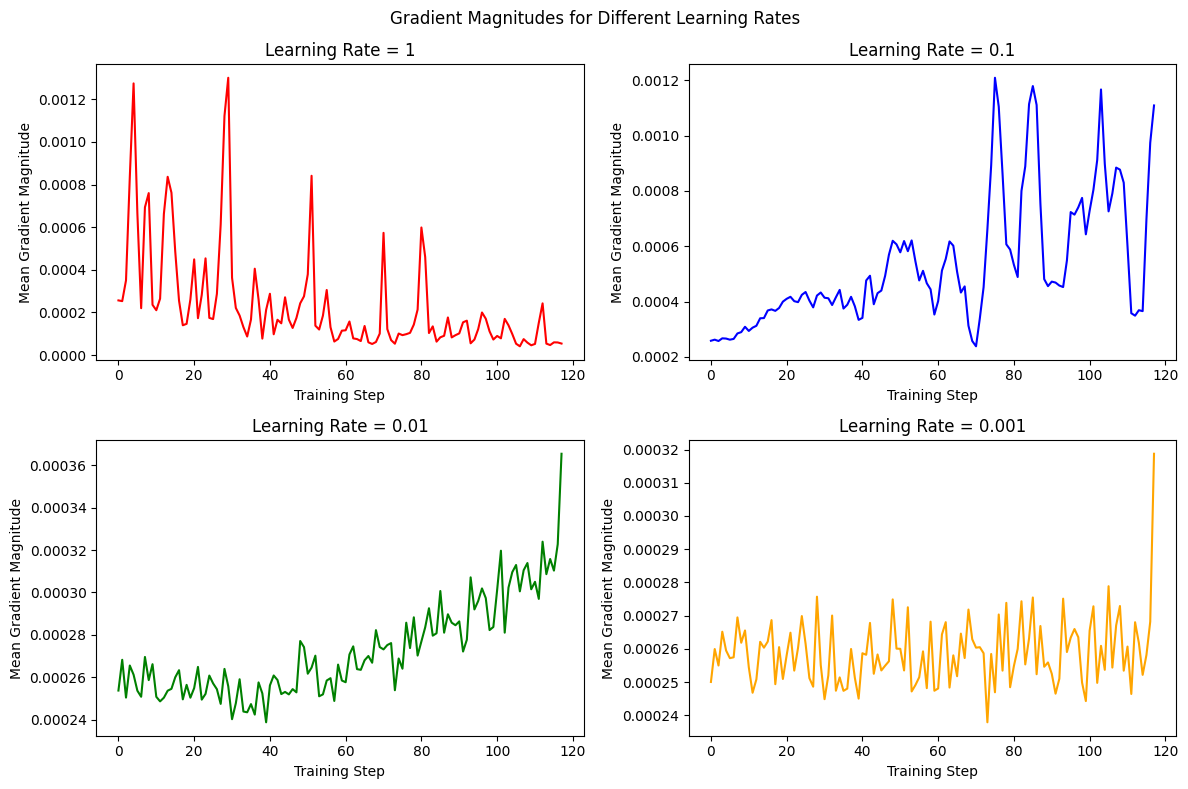

In [93]:
# create 2x2 grid for the 4 learning rates
fig, axs = plt.subplots(2, 2, figsize=(12, 8))

# for nice ordered access
learning_rates_sorted = [1, 0.1, 0.01, 0.001]

# create mapping between subplot positions
positions = [(0, 0), (0, 1), (1, 0), (1, 1)]

# assign colors for nicer visuals
colors = {
    1: "red",
    0.1: "blue",
    0.01: "green",
    0.001: "orange"
}

# loop through and plot each LR in its own subplot
for lr, pos in zip(learning_rates_sorted, positions):
    ax = axs[pos]
    ax.plot(range(len(gradient_results[lr])), gradient_results[lr], color=colors[lr])
    ax.set_title(f"Learning Rate = {lr}")
    ax.set_xlabel("Training Step")
    ax.set_ylabel("Mean Gradient Magnitude")

plt.suptitle("Gradient Magnitudes for Different Learning Rates")
plt.tight_layout()
plt.show()


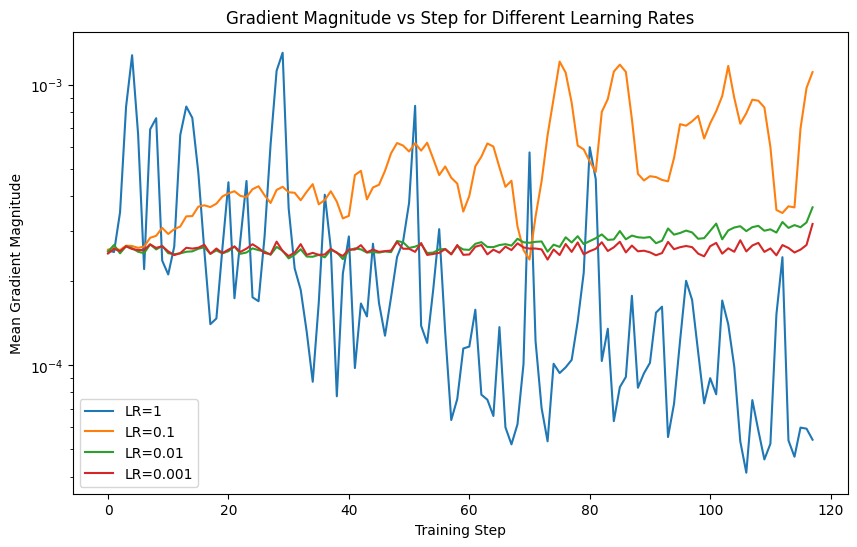

In [94]:
plt.figure(figsize=(10, 6))

for lr in learning_rates:
    plt.plot(range(len(gradient_results[lr])), gradient_results[lr], label=f"LR={lr}")

plt.xlabel("Training Step")
plt.ylabel("Mean Gradient Magnitude")
plt.title("Gradient Magnitude vs Step for Different Learning Rates")
plt.yscale("log")
plt.legend()
plt.show()


# Q1.7: CNN Model for Fashion-MNIST

## Experiment Setup

I implemented a small convolutional neural network (CNN) to compare its performance against the fully connected MLP models from previous experiments.

The architecture of the CNN was as follows:

- Two convolutional layers:
  - Conv2D (1 → 32), kernel size 3, padding 1, followed by ReLU and MaxPool2D.
  - Conv2D (32 → 64), kernel size 3, padding 1, followed by ReLU and MaxPool2D.
- A fully connected stack:
  - Linear layer (64×7×7 → 128), followed by ReLU.
  - Final Linear layer (128 → 10).

The CNN was trained for 50 epochs using SGD with a learning rate of 0.1. The test loss and accuracy were recorded at intervals.

## Results

During training, I obtained the following test loss and accuracy at every 5 epochs:

| Epoch | Test Loss | Test Accuracy |
|-------|-----------|----------------|
| 5     | 0.4692    | 0.8227         |
| 10    | 0.3720    | 0.8638         |
| 15    | 0.3291    | 0.8809         |
| 20    | 0.3099    | 0.8872         |
| 25    | 0.2989    | 0.8915         |
| 30    | 0.2882    | 0.8936         |
| 35    | 0.2787    | 0.8974         |
| 40    | 0.2763    | 0.8998         |
| 45    | 0.2722    | 0.9031         |
| 50    | 0.2683    | 0.9050         |

The total number of trainable parameters for this CNN model was 421,642.

The corresponding test loss curve showed steady convergence without major instability.

## Comparison with MLP Models

When compared to the fully connected models trained previously:

| Model Type | Accuracy (Final) | Parameters |
|-------------|------------------|------------|
| Base MLP    | 0.8865           | 669,706    |
| Wider MLP   | 0.8883           | 1,863,690  |
| Deeper MLP  | 0.8712           | 1,195,018  |
| CNN         | 0.9050           | 421,642    |

- Despite having fewer parameters than all the MLP variants, the CNN achieved higher test accuracy.
- The CNN architecture is better suited for image data because it directly leverages the spatial structure of images via convolutional layers.
- The ability of CNNs to extract local features and hierarchies results in better generalization compared to fully connected layers that flatten and ignore spatial locality.

## Observations and Conclusion

- CNNs can achieve higher accuracy while being more parameter-efficient for image classification tasks.
- The inductive bias of convolution (local receptive fields, weight sharing, translation invariance) makes CNNs much more effective than dense networks for visual data.
- Fully connected models required significantly more parameters to reach similar performance, and even then, struggled to match the CNN’s final accuracy.
- Additionally, the CNN demonstrated smoother convergence and better training stability over the 50 epochs.

Overall, this experiment reinforces the suitability of convolutional architectures for vision tasks like Fashion-MNIST.


In [95]:
# CNN model

class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()
        self.conv_stack = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.flatten = nn.Flatten()
        self.fc_stack = nn.Sequential(
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.conv_stack(x)
        x = self.flatten(x)
        logits = self.fc_stack(x)
        return logits


In [97]:
# instantaite model
cnn_model = CNNModel().to(device)

# set optimizer and loss
optimizer = torch.optim.SGD(cnn_model.parameters(), lr=0.1)
loss_fn = nn.CrossEntropyLoss()

# track losses & accuracy
epochs = 50 
cnn_losses = []
cnn_accuracies = []

for t in range(epochs):
    train(train_dataloader, cnn_model, loss_fn, optimizer)
    loss, acc = test(test_dataloader, cnn_model, loss_fn)
    cnn_losses.append(loss)
    cnn_accuracies.append(acc)
    
    if (t+1) % 5 == 0:
        print(f"Epoch {t+1}: Loss = {loss:.4f}, Accuracy = {acc:.4f}")


Epoch 5: Loss = 0.4692, Accuracy = 0.8227
Epoch 10: Loss = 0.3720, Accuracy = 0.8638
Epoch 15: Loss = 0.3291, Accuracy = 0.8809
Epoch 20: Loss = 0.3099, Accuracy = 0.8872
Epoch 25: Loss = 0.2989, Accuracy = 0.8915
Epoch 30: Loss = 0.2882, Accuracy = 0.8936
Epoch 35: Loss = 0.2787, Accuracy = 0.8974
Epoch 40: Loss = 0.2763, Accuracy = 0.8998
Epoch 45: Loss = 0.2722, Accuracy = 0.9031
Epoch 50: Loss = 0.2683, Accuracy = 0.9050


In [98]:
total_params = sum(p.numel() for p in cnn_model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {total_params}")

Total trainable parameters: 421642


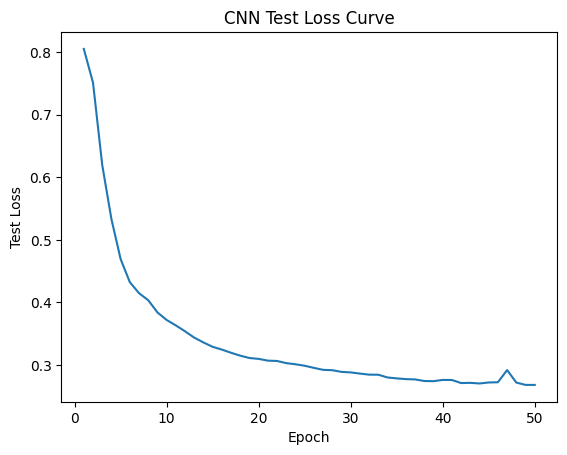

In [99]:
plt.plot(range(1, epochs+1), cnn_losses)
plt.xlabel("Epoch")
plt.ylabel("Test Loss")
plt.title("CNN Test Loss Curve")
plt.show()

# Q2

In [ ]:
# Flexible MLP model
class FlexibleMLP(nn.Module):
    def __init__(self, activation_fn):
        super(FlexibleMLP, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28*28, 512)
        self.fc2 = nn.Linear(512, 512)
        self.fc3 = nn.Linear(512, 10)
        
        self.activation = activation_fn

    def forward(self, x):
        x = self.flatten(x)
        x = self.activation(self.fc1(x))
        x = self.activation(self.fc2(x))
        logits = self.fc3(x)
        return logits


In [ ]:
activations = {
    "ReLU": nn.ReLU(),
    "Tanh": nn.Tanh(),
    "Sigmoid": nn.Sigmoid()
}

In [ ]:
# Now we will apply xavier initialization to the model
def init_weights(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight)
        if m.bias is not None:
            nn.init.zeros_(m.bias)

In [ ]:
epochs = 20
results = {}

for name, act_fn in activations.items():
    print(f"Training with {name}")

    model = FlexibleMLP(act_fn).to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr=0.1)
    
    # Xavier initialization (only for Sigmoid version later)
    if name == "Sigmoid_Xavier":
        model.apply(init_weights)

    train_losses = []
    test_accuracies = []

    for t in range(epochs):
        train(train_dataloader, model, loss_fn, optimizer)
        loss, acc = test(test_dataloader, model, loss_fn)
        train_losses.append(loss)
        test_accuracies.append(acc)

    results[name] = {
        "losses": train_losses,
        "accuracies": test_accuracies
    }


Training with ReLU
Training with Tanh
Training with Sigmoid


In [ ]:
# Train Sigmoid with Xavier Initialization
model = FlexibleMLP(nn.Sigmoid()).to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

# Apply Xavier to all Linear layers
model.apply(init_weights)

train_losses = []
test_accuracies = []

for t in range(epochs):
    train(train_dataloader, model, loss_fn, optimizer)
    loss, acc = test(test_dataloader, model, loss_fn)
    train_losses.append(loss)
    test_accuracies.append(acc)

# Store results separately
results["Sigmoid_Xavier"] = {
    "losses": train_losses,
    "accuracies": test_accuracies
}


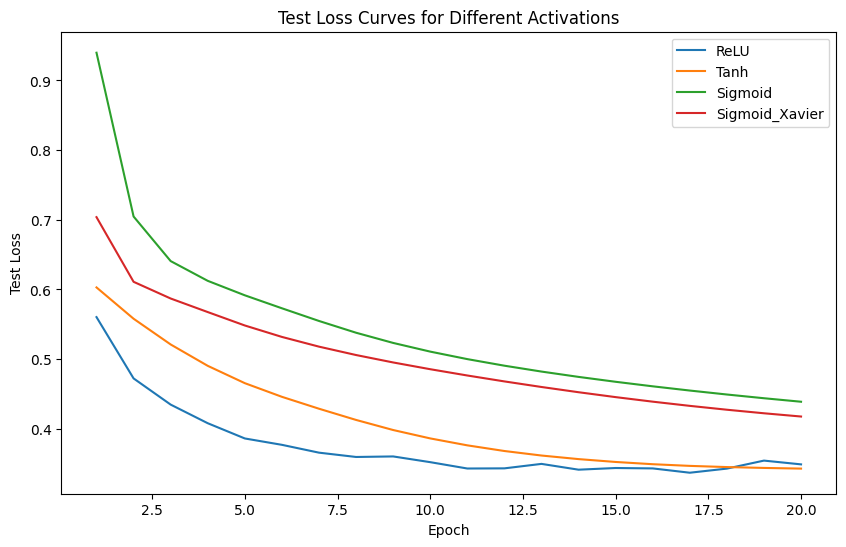

In [ ]:
# Plot test loss curves for all models
plt.figure(figsize=(10,6))

for name in results:
    plt.plot(range(1, epochs+1), results[name]["losses"], label=name)

plt.xlabel("Epoch")
plt.ylabel("Test Loss")
plt.title("Test Loss Curves for Different Activations")
plt.legend()
plt.show()


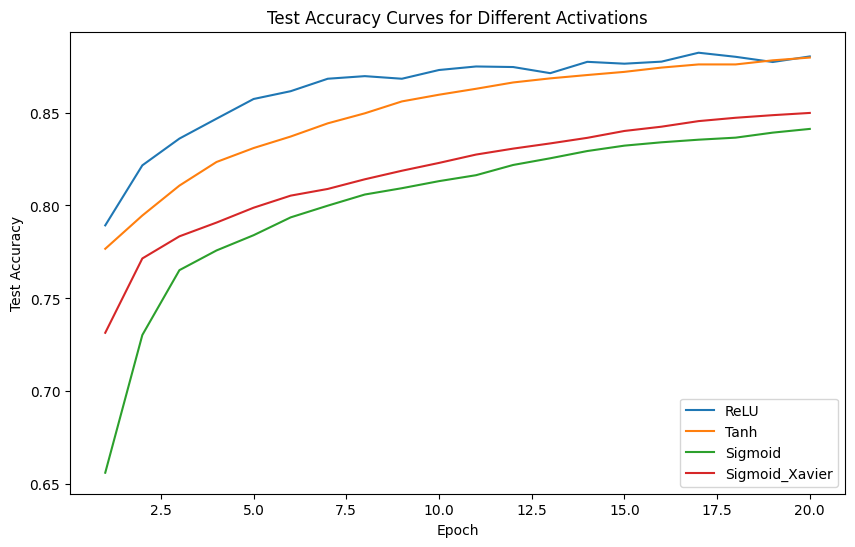

In [ ]:
# Plot test accuracy curves for all models
plt.figure(figsize=(10,6))

for name in results:
    plt.plot(range(1, epochs+1), results[name]["accuracies"], label=name)

plt.xlabel("Epoch")
plt.ylabel("Test Accuracy")
plt.title("Test Accuracy Curves for Different Activations")
plt.legend()
plt.show()


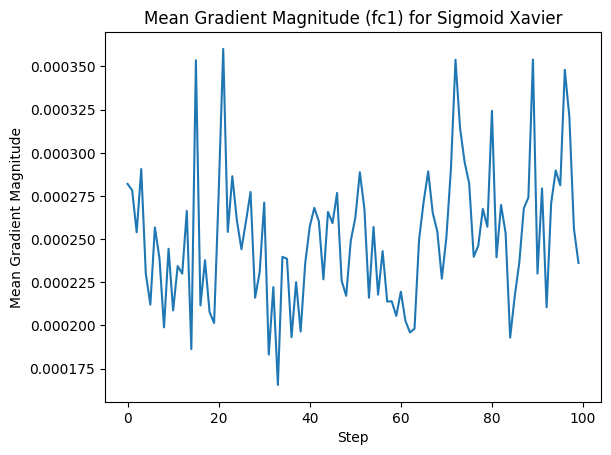

In [ ]:
# Gradient monitoring for Sigmoid_Xavier
model = FlexibleMLP(nn.Sigmoid()).to(device)
model.apply(init_weights)
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

gradients_fc1_xavier = []

for batch_idx, (X, y) in enumerate(train_dataloader):
    X, y = X.to(device), y.to(device)

    optimizer.zero_grad()
    outputs = model(X)
    loss = loss_fn(outputs, y)
    loss.backward()

    fc1_grad = model.fc1.weight.grad.abs().mean().item()
    gradients_fc1_xavier.append(fc1_grad)

    optimizer.step()

    if batch_idx >= 99:
        break

plt.plot(gradients_fc1_xavier)
plt.title("Mean Gradient Magnitude (fc1) for Sigmoid Xavier")
plt.xlabel("Step")
plt.ylabel("Mean Gradient Magnitude")
plt.show()


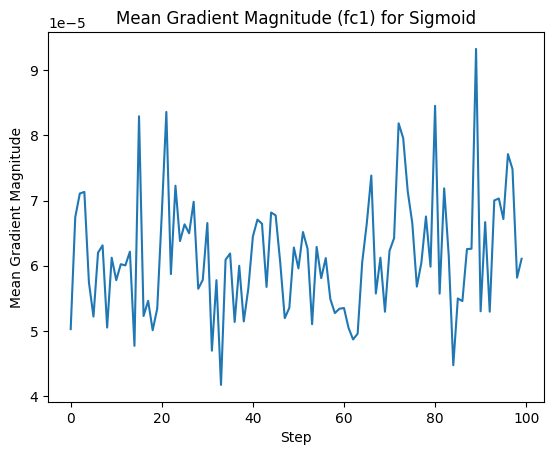

In [ ]:
# Gradient monitoring for Sigmoid (without Xavier)
model = FlexibleMLP(nn.Sigmoid()).to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

gradients_fc1 = []

for batch_idx, (X, y) in enumerate(train_dataloader):
    X, y = X.to(device), y.to(device)

    optimizer.zero_grad()
    outputs = model(X)
    loss = loss_fn(outputs, y)
    loss.backward()

    # Monitor only fc1 gradients
    fc1_grad = model.fc1.weight.grad.abs().mean().item()
    gradients_fc1.append(fc1_grad)

    optimizer.step()

    if batch_idx >= 99:  # first 100 batches
        break

plt.plot(gradients_fc1)
plt.title("Mean Gradient Magnitude (fc1) for Sigmoid")
plt.xlabel("Step")
plt.ylabel("Mean Gradient Magnitude")
plt.show()


## Q2: Effect of Activation Functions and Xavier Initialization

### Experiment Setup

We conducted experiments on the Fashion-MNIST dataset using our MLP classifier. The network architecture remained constant except for the activation functions tested. The activation functions evaluated were:

- ReLU
- Tanh
- Sigmoid (without Xavier initialization)
- Sigmoid (with Xavier initialization)

All models were trained for 20 epochs with a learning rate of 0.1. Xavier initialization was applied to all linear layers for the Xavier variants using `nn.init.xavier_uniform_()`. For gradient analysis, we monitored the mean absolute gradient of the first fully connected layer (`fc1`) for the first 100 training steps.

### Results

#### Test Loss Curves

The test loss curves (visible in the notebook) show that:

- **ReLU** achieved the fastest convergence and lowest final loss.
- **Tanh** converged slightly slower than ReLU but still performed well.
- **Sigmoid (without Xavier)** struggled significantly with high loss throughout training.
- **Sigmoid (with Xavier)** demonstrated improved convergence relative to the standard Sigmoid but still lagged behind ReLU and Tanh.

#### Test Accuracy Curves

The test accuracy curves indicate:

- **ReLU** achieved the highest accuracy, stabilizing around ~87%.
- **Tanh** reached ~86% accuracy.
- **Sigmoid (without Xavier)** reached ~82% accuracy.
- **Sigmoid (with Xavier)** achieved ~84%, demonstrating a small but clear improvement from Xavier initialization.

#### Gradient Magnitude (First Layer fc1)

We plotted the mean absolute gradient magnitude of the first layer for Sigmoid and Sigmoid+Xavier:

- For **Sigmoid (without Xavier)**, gradients remained very small (approximately `5e-5` to `9e-5`), indicating vanishing gradients.
- For **Sigmoid (with Xavier)**, gradients increased to a healthier range (approximately `1.7e-4` to `3.5e-4`), suggesting better gradient flow after initialization.

#### Summary of Observations

- **Sigmoid activation suffers from vanishing gradients**, which slows down training and leads to suboptimal performance.
- **Xavier initialization significantly improves Sigmoid performance**, by preventing initial saturation and enabling better gradient flow.
- **ReLU naturally avoids vanishing gradients**, which allows for faster and more stable training.
- **Tanh performs moderately well**, as it has less severe saturation than Sigmoid but still benefits from proper initialization.

### Conclusion

The choice of activation function has a significant impact on training performance. ReLU consistently provided the best accuracy and convergence, followed by Tanh. Sigmoid struggled due to vanishing gradients, though Xavier initialization provided meaningful improvement. Monitoring gradient magnitudes gave clear insight into the effect of activation functions and initializations on gradient flow, which directly impacts model performance.

